# SkyCoach AI - Phase 1 Submission Notebook

This notebook is a standalone Phase 1 submission prepared from the SkyCoach AI project. It is intentionally descriptive and walks through the assignment requirements in the same order as the submission brief.

## What this notebook demonstrates
- Dataset description and feature overview
- Pandas preprocessing
- Matplotlib and Seaborn visualization
- Two text-classification models
- Working demonstration of the first model

## Dataset used
The notebook uses the SkyCoach activity-intent dataset bundled inside this submission package under `data/datasets`. The raw inputs are short activity phrases and the labels describe whether the activity is indoor, outdoor, mixed, or unclear.

In [39]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

## 1. Dataset description and features

The SkyCoach dataset is a short-text classification dataset used by the application to decide whether a user activity is indoor or outdoor and to support the broader weather-aware planner.

### Raw dataset columns
- `phrase`: text input provided by the user
- `label`: target class used by the project models
- `split`: added in this notebook so the dataset source of each row is visible during analysis

### Labels
- Indoor
- Outdoor
- Mixed
- Unclear

### Feature types
- `phrase`: text
- `label`: categorical
- `split`: categorical
- engineered features such as phrase length and token count: numerical

In [40]:
def find_dataset_root() -> Path:
    candidates = [Path.cwd(), *Path.cwd().parents]
    for base in candidates:
        direct = base / 'data' / 'datasets'
        if (direct / 'train.jsonl').exists():
            return direct
        nested = base / 'ml_system' / 'data' / 'datasets'
        if (nested / 'train.jsonl').exists():
            return nested
    raise FileNotFoundError('Could not locate the bundled dataset folder')

dataset_root = find_dataset_root()
print('Dataset root:', dataset_root)

splits = {
    'train': dataset_root / 'train.jsonl',
    'val': dataset_root / 'val.jsonl',
    'test': dataset_root / 'test.jsonl',
    'hardset': dataset_root / 'hardset.jsonl',
}

def load_jsonl(path: Path) -> pd.DataFrame:
    rows = []
    with path.open('r', encoding='utf-8') as handle:
        for line in handle:
            line = line.strip()
            if not line:
                continue
            rows.append(json.loads(line))
    return pd.DataFrame(rows)

frames = []
for split_name, split_path in splits.items():
    frame = load_jsonl(split_path)
    frame['split'] = split_name
    frames.append(frame)

df = pd.concat(frames, ignore_index=True)
print('Loaded shape:', df.shape)
display(df.head())

Dataset root: e:\Java\Project\Project Ai\phase1_submission_package\data\datasets
Loaded shape: (140000, 3)


,phrase,label,split
0,today i will start an open task later today,Unclear,train
1,We are listen music practice at home later tod...,Indoor,train
2,Planning to ride a mountain path outside tonig...,Outdoor,train
3,Can we reflect something importnat after lunch,Unclear,train
4,I am gooing to figure out a personal thing tom...,Unclear,train


## 2. Pandas preprocessing

The next step is to clean the dataset and create simple numerical features that help us understand the structure of the text inputs. The notebook checks missing values, handles them safely, converts types, and prints useful dataset statistics.

In [41]:
missing = df.isna().sum().sort_values(ascending=False)
print('Missing values per column:')
display(missing.to_frame(name='missing_count'))

# Handle missing values conservatively
df['phrase'] = df['phrase'].fillna('').astype(str)
df = df.dropna(subset=['label']).copy()

# Remove duplicate phrase/label combinations if any appear
df = df.drop_duplicates(subset=['phrase', 'label', 'split']).copy()

# Engineered features for exploration
df['phrase_length'] = df['phrase'].str.len().astype('int64')
df['token_count'] = df['phrase'].str.split().str.len().fillna(0).astype('int64')

# Type conversion for cleaner analysis output
df['label'] = df['label'].astype('category')
df['split'] = df['split'].astype('category')

print('Shape after preprocessing:', df.shape)
display(df[['phrase', 'label', 'split', 'phrase_length', 'token_count']].head())
display(df[['phrase_length', 'token_count']].describe())

Missing values per column:


,missing_count
phrase,0
label,0
split,0


Shape after preprocessing: (140000, 5)


,phrase,label,split,phrase_length,token_count
0,today i will start an open task later today,Unclear,train,43,9
1,We are listen music practice at home later tod...,Indoor,train,61,11
2,Planning to ride a mountain path outside tonig...,Outdoor,train,55,9
3,Can we reflect something importnat after lunch,Unclear,train,46,7
4,I am gooing to figure out a personal thing tom...,Unclear,train,59,11


,phrase_length,token_count
count,140000.000000,140000.000000
mean,57.673500,10.402357
std,13.755095,2.175989
min,20.000000,5.000000
25%,48.000000,9.000000
50%,56.000000,10.000000
75%,66.000000,12.000000
max,110.000000,17.000000


In [42]:
# Outlier inspection using the IQR method on phrase length
q1 = df['phrase_length'].quantile(0.25)
q3 = df['phrase_length'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outlier_mask = (df['phrase_length'] < lower_bound) | (df['phrase_length'] > upper_bound)
print('IQR lower bound:', lower_bound)
print('IQR upper bound:', upper_bound)
print('Outlier rows detected:', int(outlier_mask.sum()))

# Use capping to keep the dataset stable for plotting and modeling
df['phrase_length_capped'] = df['phrase_length'].clip(lower=0, upper=int(upper_bound))
display(df[['phrase_length', 'phrase_length_capped']].describe())

IQR lower bound: 21.0
IQR upper bound: 93.0
Outlier rows detected: 1000


,phrase_length,phrase_length_capped
count,140000.000000,140000.000000
mean,57.673500,57.647771
std,13.755095,13.683558
min,20.000000,20.000000
25%,48.000000,48.000000
50%,56.000000,56.000000
75%,66.000000,66.000000
max,110.000000,93.000000


## 3. Data visualization with Matplotlib and Seaborn

The following charts help us understand the dataset shape and the relationship between simple engineered features. Because the core task is short-text classification, the distributions are more useful than complex numeric correlations.

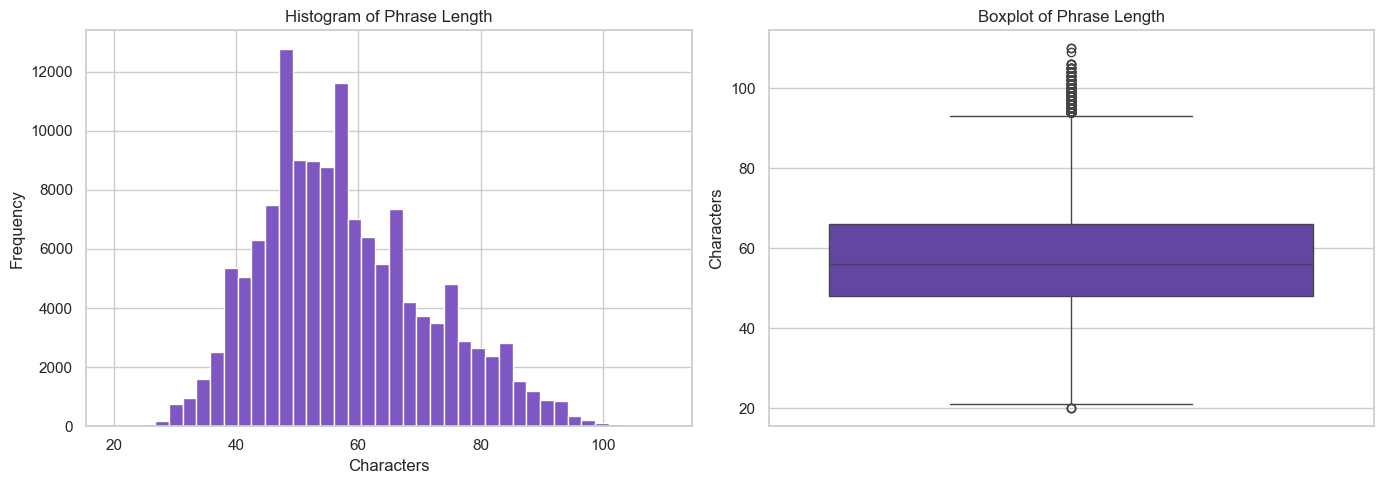

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['phrase_length'], bins=40, color='#7e57c2', edgecolor='white')
axes[0].set_title('Histogram of Phrase Length')
axes[0].set_xlabel('Characters')
axes[0].set_ylabel('Frequency')

sns.boxplot(y=df['phrase_length'], ax=axes[1], color='#5e35b1')
axes[1].set_title('Boxplot of Phrase Length')
axes[1].set_ylabel('Characters')

plt.tight_layout()
plt.show()

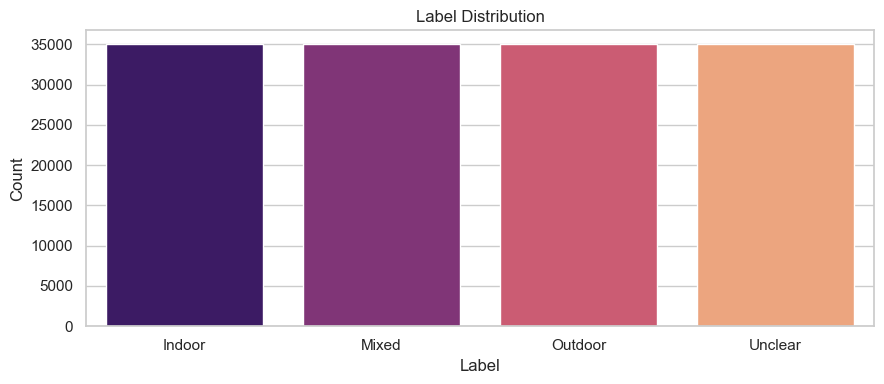

In [44]:
plt.figure(figsize=(9, 4))
label_counts = df['label'].value_counts().sort_values(ascending=False)
label_frame = label_counts.reset_index()
label_frame.columns = ['label', 'count']
sns.barplot(data=label_frame, x='label', y='count', hue='label', palette='magma', legend=False)
plt.title('Label Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

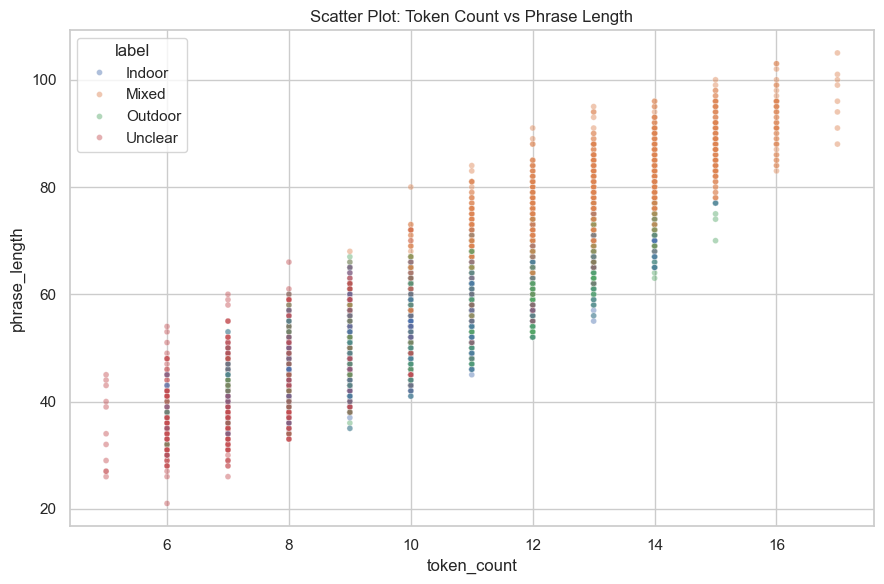

In [45]:
sample_scatter = df.sample(min(6000, len(df)), random_state=42)

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=sample_scatter,
    x='token_count',
    y='phrase_length',
    hue='label',
    alpha=0.45,
    s=18
)
plt.title('Scatter Plot: Token Count vs Phrase Length')
plt.tight_layout()
plt.show()

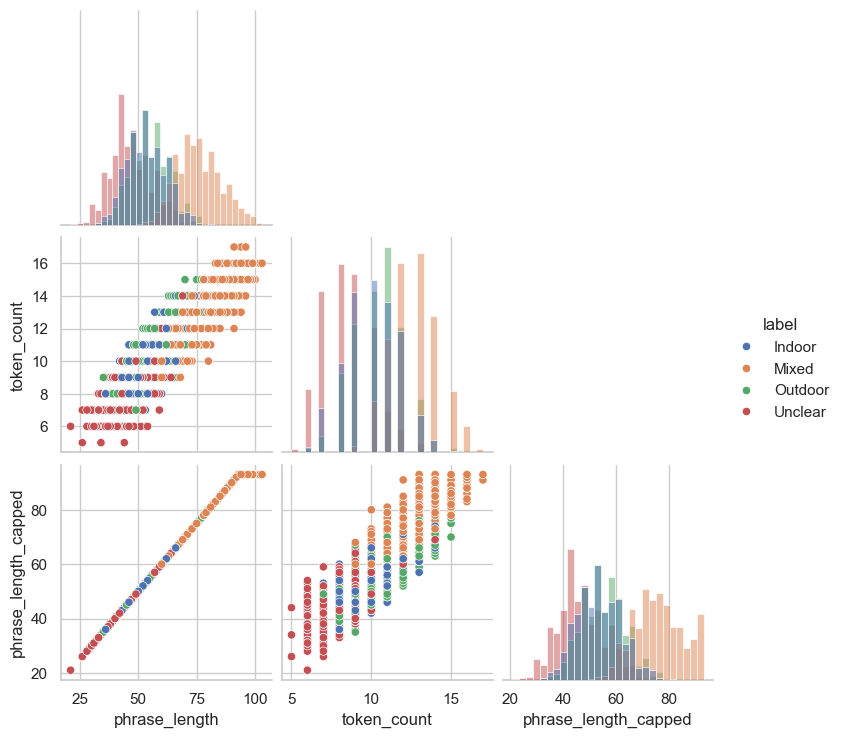

In [46]:
pair_sample = df[['phrase_length', 'token_count', 'phrase_length_capped', 'label']].sample(min(3000, len(df)), random_state=42)
sns.pairplot(pair_sample, hue='label', corner=True, diag_kind='hist')
plt.show()

## 4. Methodology

The project uses text classification because the input is a short phrase and the target is a discrete activity class. For Phase 1, a strong and explainable baseline is appropriate, and a second model is included to satisfy the requirement for at least two models.

### Techniques Used in This Notebook
- Text vectorization: TF-IDF (with unigram and bigram features)
- Probabilistic model: Multinomial Naive Bayes
- Linear model: Logistic Regression
- Validation setup: fixed train/test split from provided dataset files
- Evaluation: accuracy, classification report, and confusion matrix
- Data handling: pandas preprocessing, duplicate handling, and outlier inspection (IQR)

### Model 1
TF-IDF + Multinomial Naive Bayes

Why this model fits:
- Very strong baseline for short text
- Fast to train
- Easy to interpret
- Works well with sparse word features

### Model 2
TF-IDF + Logistic Regression

Why this model fits:
- Handles sparse text features well
- Often performs strongly on text classification
- Gives a useful comparison against Naive Bayes
- Supports a clear benchmark for later project phases

### Additional Techniques (Not Applied in This Phase)
- Min-Max scaling: typically useful for continuous numeric features; not required for sparse TF-IDF pipelines used here
- Genetic optimization: can be used in future phases for hyperparameter search (for example, n-gram range, regularization strength, and class weights)
- Ensemble methods: can combine multiple classifiers in later phases for robustness

In [47]:
train_df = df[df['split'] == 'train'].copy()
test_df = df[df['split'] == 'test'].copy()

X_train = train_df['phrase']
y_train = train_df['label'].astype(str)
X_test = test_df['phrase']
y_test = test_df['label'].astype(str)

print('Train size:', len(train_df))
print('Test size:', len(test_df))
print('Train labels:')
display(y_train.value_counts())

Train size: 98000
Test size: 14000
Train labels:


label
Unclear    24500
Indoor     24500
Outdoor    24500
Mixed      24500
Name: count, dtype: int64

Model 1: TF-IDF + Multinomial Naive Bayes
Test accuracy: 1.0000

Classification report:
              precision    recall  f1-score   support

      Indoor       1.00      1.00      1.00      3500
       Mixed       1.00      1.00      1.00      3500
     Outdoor       1.00      1.00      1.00      3500
     Unclear       1.00      1.00      1.00      3500

    accuracy                           1.00     14000
   macro avg       1.00      1.00      1.00     14000
weighted avg       1.00      1.00      1.00     14000



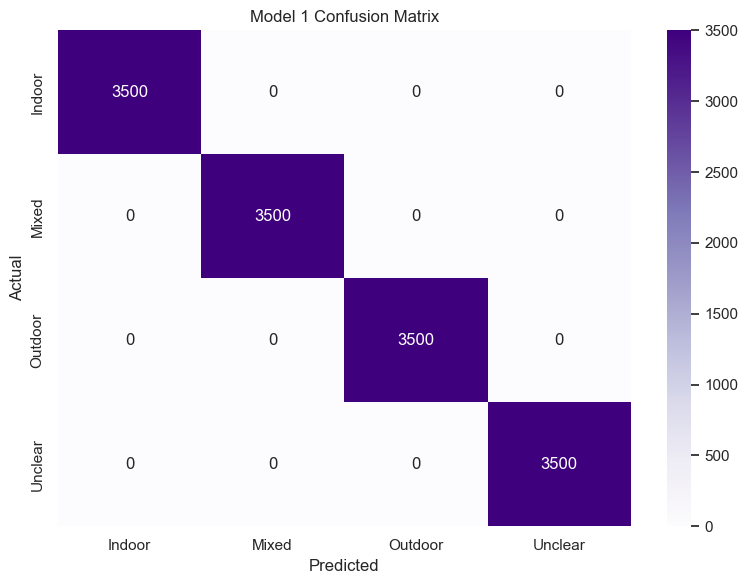

In [48]:
# Model 1: TF-IDF + Multinomial Naive Bayes
model_1 = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), min_df=2)),
    ('nb', MultinomialNB(alpha=0.5)),
])

model_1.fit(X_train, y_train)
pred_1 = model_1.predict(X_test)
acc_1 = accuracy_score(y_test, pred_1)

print('Model 1: TF-IDF + Multinomial Naive Bayes')
print(f'Test accuracy: {acc_1:.4f}')
print('\nClassification report:')
print(classification_report(y_test, pred_1))

cm_1 = confusion_matrix(y_test, pred_1, labels=sorted(y_test.unique()))
plt.figure(figsize=(8, 6))
sns.heatmap(cm_1, annot=True, fmt='d', cmap='Purples', xticklabels=sorted(y_test.unique()), yticklabels=sorted(y_test.unique()))
plt.title('Model 1 Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [49]:
# Model 2: TF-IDF + Logistic Regression
model_2 = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), min_df=2)),
    ('lr', LogisticRegression(max_iter=2000)),
])

model_2.fit(X_train, y_train)
pred_2 = model_2.predict(X_test)
acc_2 = accuracy_score(y_test, pred_2)

print('Model 2: TF-IDF + Logistic Regression')
print(f'Test accuracy: {acc_2:.4f}')
print('\nClassification report:')
print(classification_report(y_test, pred_2))

Model 2: TF-IDF + Logistic Regression
Test accuracy: 1.0000

Classification report:
              precision    recall  f1-score   support

      Indoor       1.00      1.00      1.00      3500
       Mixed       1.00      1.00      1.00      3500
     Outdoor       1.00      1.00      1.00      3500
     Unclear       1.00      1.00      1.00      3500

    accuracy                           1.00     14000
   macro avg       1.00      1.00      1.00     14000
weighted avg       1.00      1.00      1.00     14000

